# Chapter 3 — State-space models

The executable counterpart of `docs/companion/04-ch3-state-space.md`: the TVP regression on the handbook's artificial DGP (examples 1–2), the unobserved-components trend–cycle model (§2), the TVP-VAR (example 3) and the DFM block of the FAVAR (example 4).

In [1]:
from pathlib import Path
import os
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from macrotoolkit import api as mtk
from macrotoolkit.run import REPO_ROOT as REPO   # never walk parent directories (HANDOFF warning)

HB = REPO / "examples" / "handbook"
HEAVY = os.environ.get("HANDBOOK_HEAVY") == "1"

def fit(name):
    """Fit an example spec (reused by hash if the run exists) and print its record."""
    run = mtk.fit(str(HB / name / "spec.yaml"))
    mc = run.mirror_check
    print(f"{name}: run {run.hash} | verdict {run.verdict} | {'; '.join(run.diagnostics['reasons'])}")
    print(f"  fit-time mirror check: max |Stan - Python| KF loglik = {mc['max_abs_diff']:.2e} over {mc['n_points']} prior draws")
    return run

def heavy(name):
    if not HEAVY:
        print(f"{name}: heavy example -- run with HANDBOOK_HEAVY=1 (a run session); skipped here.")
        return None
    return fit(name)


/root/.local/share/uv/tools/pytest/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Examples 1–2: the TVP regression — the true `√R = 0.1`, `√Q ≈ 0.032` are recovered and the smoothed β_t band contains the truth

In [2]:
run = fit("ch3_tvp_regression")
run.param_table().round(4)

ch3_tvp_regression: run f48f15521246 | verdict WARN | min bulk/tail ESS (286/207) < 400
  fit-time mirror check: max |Stan - Python| KF loglik = 8.53e-14 over 5 prior draws


,median,ci_lo,ci_hi,rhat,ess_bulk,ess_tail
name,,,,,,
kf_loglik,380.5510,378.3260,381.2030,1.0008,286.0144,207.3504
s_e,0.0991,0.0933,0.1050,1.0070,403.3833,260.6998
s_eta,0.0276,0.0232,0.0335,1.0064,316.5485,240.9686


truth inside the 90% band at 91.0% of periods; RMSE of the smoothed median 0.0371


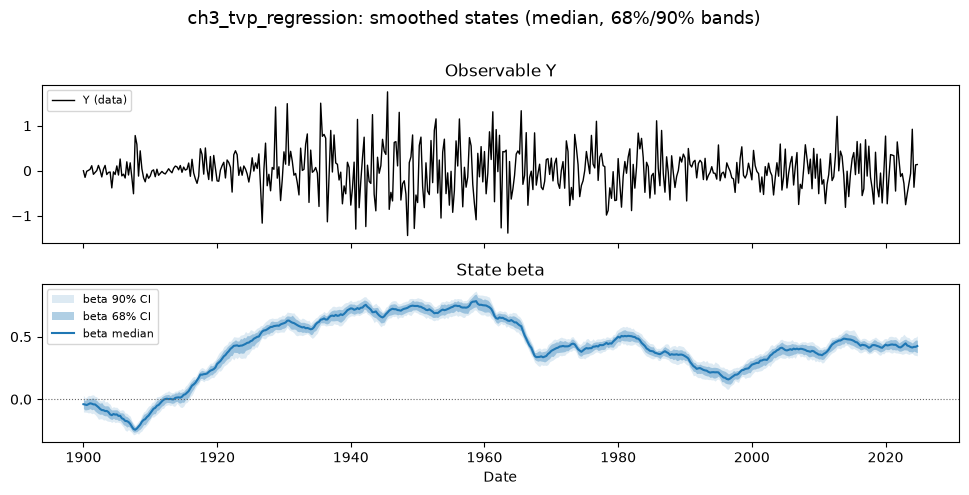

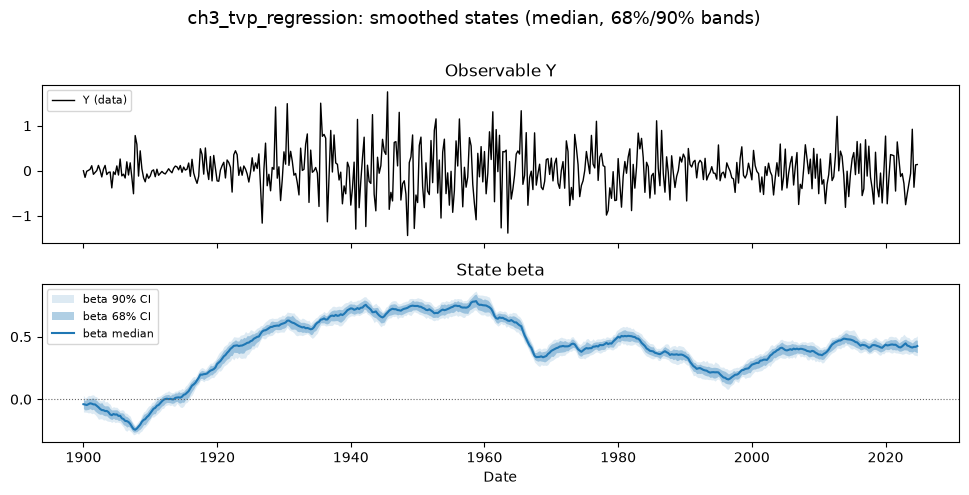

In [3]:
truth = pd.read_csv(HB / "data" / "ch3_tvp_example1_sim.csv")["beta_true"].to_numpy()
sd = run.outputs().compute("states"); beta = sd.states["beta"]
lo, hi, med = np.quantile(beta, 0.05, axis=0), np.quantile(beta, 0.95, axis=0), np.median(beta, axis=0)
print(f"truth inside the 90% band at {np.mean((truth >= lo) & (truth <= hi)):.1%} of periods; RMSE of the smoothed median {np.sqrt(np.mean((med - truth) ** 2)):.4f}")
run.outputs().figure("states")

## §2: the unobserved-components trend–cycle model on US inflation (no measurement error: a singular R)

In [4]:
run = fit("ch3_uc_trend_cycle")
run.param_table().round(4)

ch3_uc_trend_cycle: run 32ff691ff037 | verdict PASS | no divergences, treedepth hits, low E-BFMI, high R-hat, or low ESS detected
  fit-time mirror check: max |Stan - Python| KF loglik = 2.27e-13 over 5 prior draws


,median,ci_lo,ci_hi,rhat,ess_bulk,ess_tail
name,,,,,,
a1,1.5346,1.4011,1.6392,1.0051,487.3202,726.2983
a2,-0.7151,-0.8348,-0.5528,1.0038,439.6383,672.3380
c0,-0.4953,-0.9572,0.0009,0.9992,1295.7018,1098.4446
kf_loglik,-285.8810,-289.9580,-283.6380,1.0032,607.9494,721.6710
s1,0.4251,0.2344,0.6054,1.0076,460.6604,526.0342
s2,0.5353,0.3859,0.6658,1.0053,540.3324,564.9630


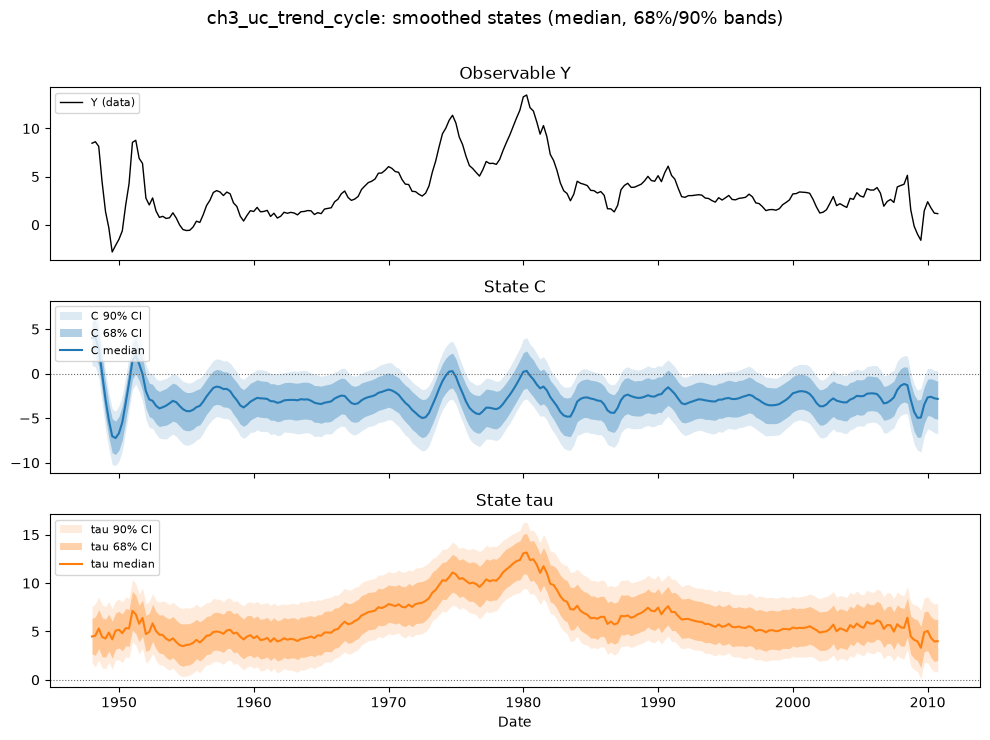

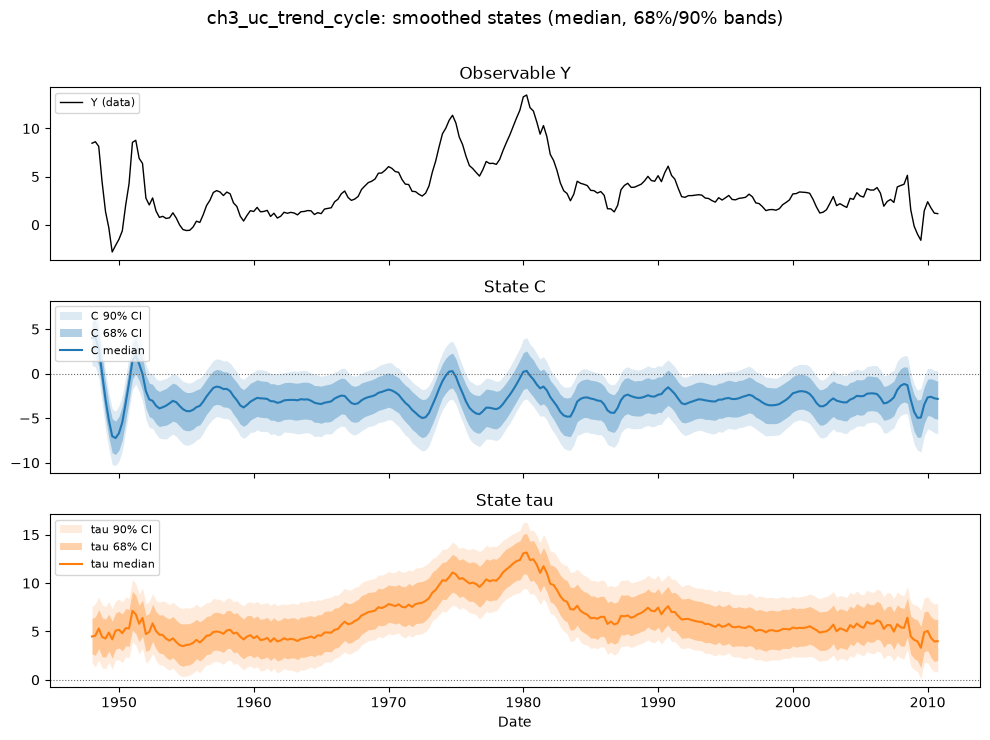

In [5]:
run.outputs().figure("states")

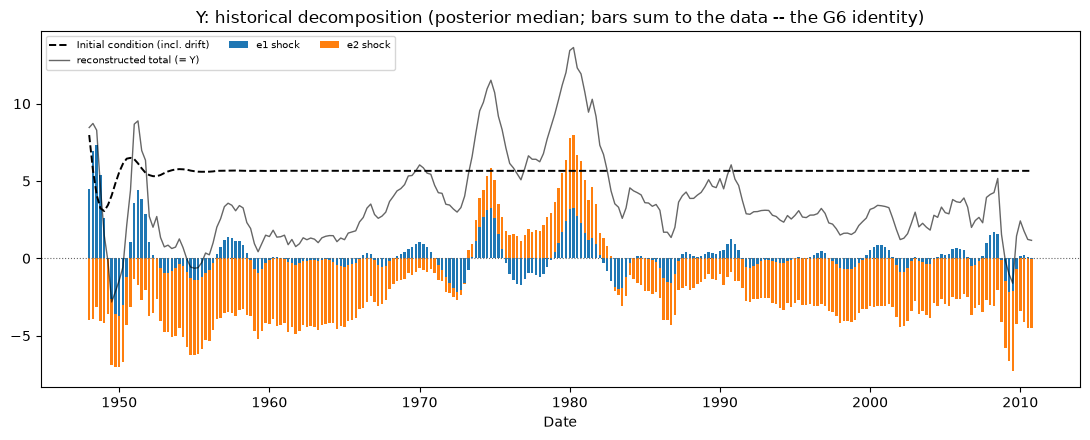

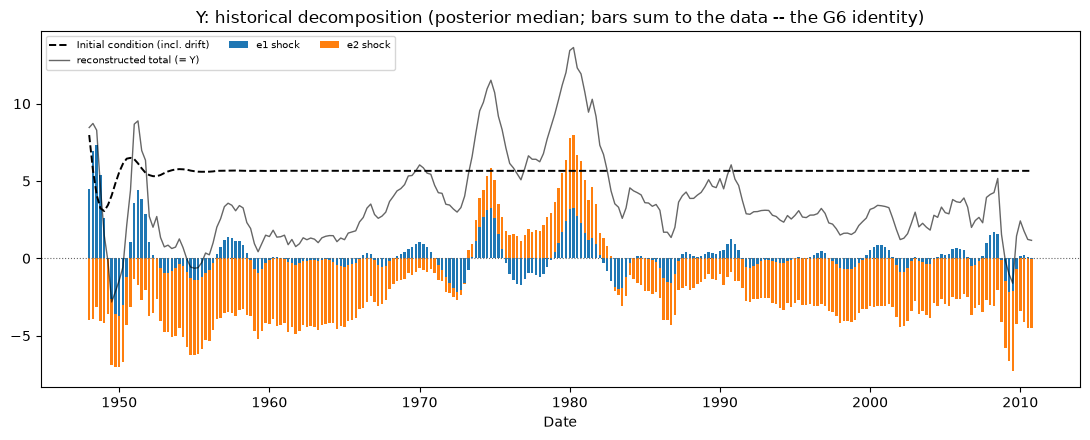

In [6]:
run.outputs().figure("hd")["Y"]

## Example 3: the TVP-VAR — IRFs conditional on the coefficient state at three dates (heavy)

In [7]:
run = heavy("ch3_tvp_var")
run.param_table().round(4) if run is not None else None

ch3_tvp_var: heavy example -- run with HANDBOOK_HEAVY=1 (a run session); skipped here.


In [8]:
if run is not None:
    irf = run.outputs().compute("irf")
    for lab, resp in irf.by_date.items():
        print(lab, {o: round(float(np.median(resp["e_ffr"][o][:, 3])), 3) for o in resp["e_ffr"]})
    run.outputs().figure("states")

## Example 4: the DFM block of the FAVAR on the 40-series UK panel (heavy)

In [9]:
run = heavy("ch3_dfm_uk_panel")
run.param_table().round(4) if run is not None else None

ch3_dfm_uk_panel: heavy example -- run with HANDBOOK_HEAVY=1 (a run session); skipped here.


In [10]:
run.outputs().figure("states") if run is not None else None

In [11]:
plt.close("all")